<a href="https://colab.research.google.com/github/va23274/CI345_ML/blob/main/HW02_By_Arsilbhai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Arsilbhai vahora

## HW-2
## 5/19/2026

# Step 1 : Loading Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
diabetes_file = '/content/drive/MyDrive/CI345_ML/data/diabetes_prediction_dataset.csv'

diabetes_table = pd.read_csv(diabetes_file)
diabetes_table.head(20)

Mounted at /content/drive


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


# Step 2 : Basic Data Ananalysis

In [3]:
df = diabetes_table.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [5]:
df.shape

(100000, 9)

In [6]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [7]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


# Step 3 : Data Visualization

---

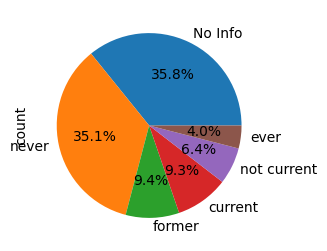

In [9]:
res = df.smoking_history.value_counts()
res.plot(kind='pie', figsize=(4,3), autopct='%1.1f%%')
plt.show()

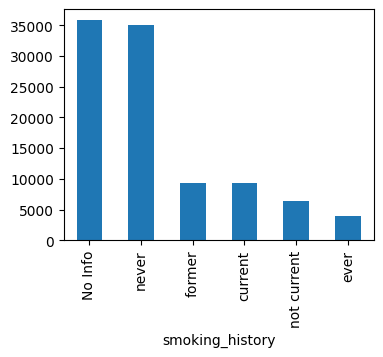

In [10]:
res = df.smoking_history.value_counts()
res.plot(kind='bar', figsize=(4,3))
plt.show()

<Axes: title={'center': 'bmi'}, ylabel='Frequency'>

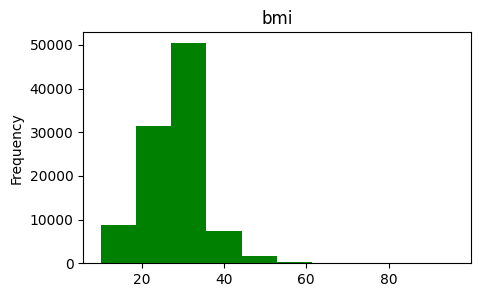

In [11]:
df = diabetes_table
res = df['bmi']
res.plot(kind='hist',bins = 10, title = 'bmi', color= 'green', figsize =( 5,3))

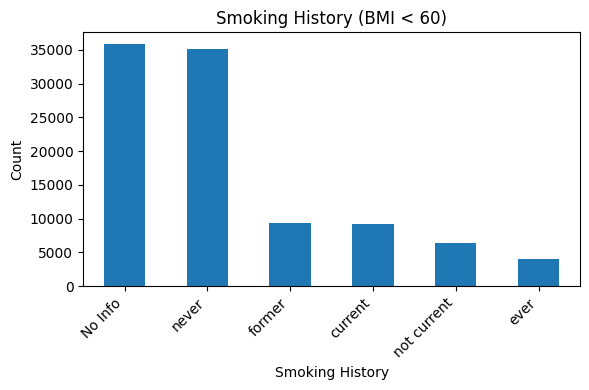

In [12]:
# Filter data for bmi < 60
df_filtered_bmi = df[df['bmi'] < 60]

# Get value counts of smoking_history for the filtered data
smoking_history_counts = df_filtered_bmi['smoking_history'].value_counts()

# Plot a bar chart
smoking_history_counts.plot(kind='bar', figsize=(6,4), title='Smoking History (BMI < 60)')
plt.xlabel('Smoking History')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'HbA1c_level'}>,
        <Axes: title={'center': 'blood_glucose_level'}>]], dtype=object)

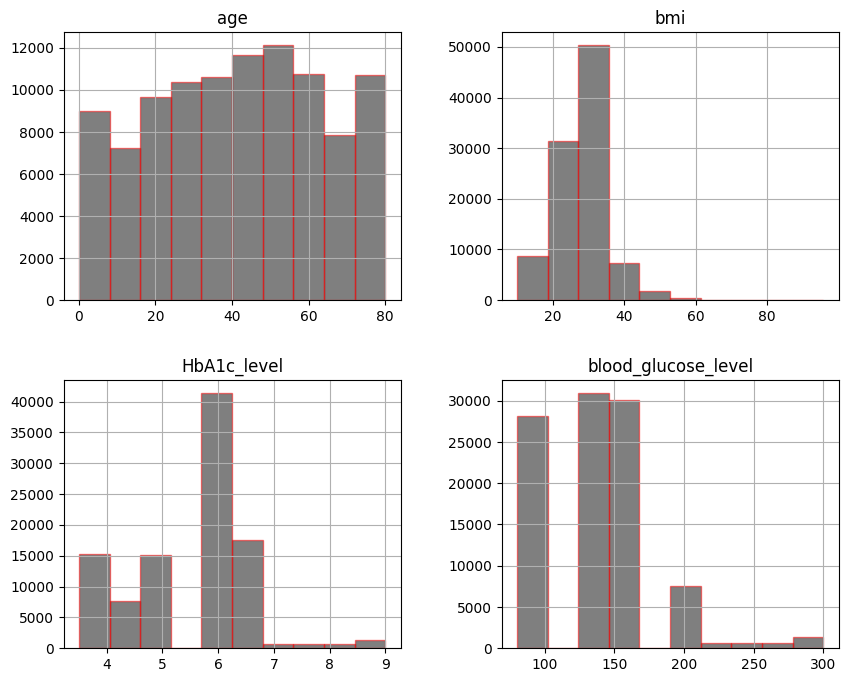

In [13]:
df = diabetes_table
res = df[['age','bmi','HbA1c_level','blood_glucose_level']]
res
res.hist(alpha = 0.5, edgecolor='red', color = 'black', figsize = (10,8))

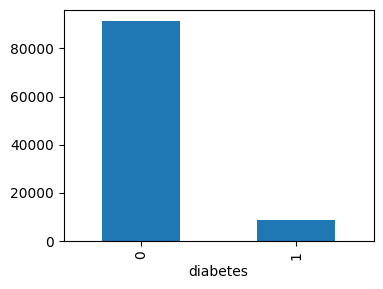

In [14]:
res = df.diabetes.value_counts()
res.plot(kind='bar', figsize=(4,3))
plt.show()

# Step 4 : processing Data

In [15]:
# Method 1 : Use LabelEncoder
df = diabetes_table.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df.head(14)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,never,25.19,6.6,140,0
1,0,54.0,0,0,No Info,27.32,6.6,80,0
2,1,28.0,0,0,never,27.32,5.7,158,0
3,0,36.0,0,0,current,23.45,5.0,155,0
4,1,76.0,1,1,current,20.14,4.8,155,0
5,0,20.0,0,0,never,27.32,6.6,85,0
6,0,44.0,0,0,never,19.31,6.5,200,1
7,0,79.0,0,0,No Info,23.86,5.7,85,0
8,1,42.0,0,0,never,33.64,4.8,145,0
9,0,32.0,0,0,never,27.32,5.0,100,0


In [16]:
print(df.head(2))
hist_map={'never':0, 'No Info':2, 'former':8, 'current':10, 'not current':5, 'ever':20}
df['smoking_history'] = df['smoking_history'].map(hist_map)
df.head(2)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0       0  80.0             0              1           never  25.19   
1       0  54.0             0              0         No Info  27.32   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140,0
1,0,54.0,0,0,2,27.32,6.6,80,0


In [17]:


import pandas as pd

category_cols = ['gender', 'smoking_history']

df_use_dummies = pd.get_dummies(
    df,
    columns=category_cols,
    dtype=int
)

print("--------")
print(df_use_dummies.dtypes)

df_use_dummies.head(2)

--------
age                    float64
hypertension             int64
heart_disease            int64
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
gender_0                 int64
gender_1                 int64
gender_2                 int64
smoking_history_0        int64
smoking_history_2        int64
smoking_history_5        int64
smoking_history_8        int64
smoking_history_10       int64
smoking_history_20       int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_0,gender_1,gender_2,smoking_history_0,smoking_history_2,smoking_history_5,smoking_history_8,smoking_history_10,smoking_history_20
0,80.0,0,1,25.19,6.6,140,0,1,0,0,1,0,0,0,0,0
1,54.0,0,0,27.32,6.6,80,0,1,0,0,0,1,0,0,0,0


In [18]:
# Current processed data has no category

print(df.columns)

cols_used = [
    'gender',
    'age',
    'hypertension',
    'heart_disease',
    'smoking_history',
    'HbA1c_level',
    'blood_glucose_level'
]

# Separate data part
data = df[cols_used]

# Get target
target = df['diabetes']

print(data.shape)
print(target.shape)
print(target.head(2))

data.head(3)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')
(100000, 7)
(100000,)
0    0
1    0
Name: diabetes, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,0,6.6,140
1,0,54.0,0,0,2,6.6,80
2,1,28.0,0,0,0,5.7,158


In [19]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) using df_use_dummies
X = df_use_dummies.drop('diabetes', axis=1)
y = df_use_dummies['diabetes']

# Split the data into training and testing sets
data_train, data_test, target_train, target_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {data_train.shape}")
print(f"Testing data shape: {data_test.shape}")

Training data shape: (70000, 15)
Testing data shape: (30000, 15)


## KNN Classifier

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Try different k numbers
k_values = [3, 5, 7]

for k in k_values:
    print(f"\n--- K-Nearest Neighbors Classifier (k={k}) ---")
    knn_classifier = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn_classifier.fit(data_train, target_train)

    # Make predictions
    predicted_knn = knn_classifier.predict(data_test)

    # Evaluate the model
    report_knn = classification_report(target_test, predicted_knn)
    print("Classification Report:")
    print(report_knn)

    matrix_knn = confusion_matrix(target_test, predicted_knn)
    print('-------- Confusion Matrix')
    print(matrix_knn)


--- K-Nearest Neighbors Classifier (k=3) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     27453
           1       0.81      0.55      0.65      2547

    accuracy                           0.95     30000
   macro avg       0.89      0.77      0.81     30000
weighted avg       0.95      0.95      0.95     30000

-------- Confusion Matrix
[[27137   316]
 [ 1158  1389]]

--- K-Nearest Neighbors Classifier (k=5) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     27453
           1       0.89      0.53      0.66      2547

    accuracy                           0.95     30000
   macro avg       0.92      0.76      0.82     30000
weighted avg       0.95      0.95      0.95     30000

-------- Confusion Matrix
[[27280   173]
 [ 1204  1343]]

--- K-Nearest Neighbors Classifier (k=7) ---
Classification Report:
              precision  

## Decision Tree Classifier

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Decision Tree Classifier ---")
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_classifier.fit(data_train, target_train)

# Make predictions
predicted_dt = decision_tree_classifier.predict(data_test)

# Evaluate the model
report_dt = classification_report(target_test, predicted_dt)
print("Classification Report:")
print(report_dt)

matrix_dt = confusion_matrix(target_test, predicted_dt)
print('-------- Confusion Matrix')
print(matrix_dt)


--- Decision Tree Classifier ---
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     27453
           1       0.71      0.74      0.72      2547

    accuracy                           0.95     30000
   macro avg       0.84      0.85      0.85     30000
weighted avg       0.95      0.95      0.95     30000

-------- Confusion Matrix
[[26694   759]
 [  670  1877]]


In [22]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) using df_use_dummies
X = df_use_dummies.drop('diabetes', axis=1)
y = df_use_dummies['diabetes']

# Split the data into training and testing sets
data_train, data_test, target_train, target_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {data_train.shape}")
print(f"Testing data shape: {data_test.shape}")

Training data shape: (70000, 15)
Testing data shape: (30000, 15)


## KNN Classifier

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Try different k numbers
k_values = [3, 5, 7]

for k in k_values:
    print(f"\n--- K-Nearest Neighbors Classifier (k={k}) ---")
    knn_classifier = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn_classifier.fit(data_train, target_train)

    # Make predictions
    predicted_knn = knn_classifier.predict(data_test)

    # Evaluate the model
    report_knn = classification_report(target_test, predicted_knn)
    print("Classification Report:")
    print(report_knn)

    matrix_knn = confusion_matrix(target_test, predicted_knn)
    print('-------- Confusion Matrix')
    print(matrix_knn)


--- K-Nearest Neighbors Classifier (k=3) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     27453
           1       0.81      0.55      0.65      2547

    accuracy                           0.95     30000
   macro avg       0.89      0.77      0.81     30000
weighted avg       0.95      0.95      0.95     30000

-------- Confusion Matrix
[[27137   316]
 [ 1158  1389]]

--- K-Nearest Neighbors Classifier (k=5) ---
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     27453
           1       0.89      0.53      0.66      2547

    accuracy                           0.95     30000
   macro avg       0.92      0.76      0.82     30000
weighted avg       0.95      0.95      0.95     30000

-------- Confusion Matrix
[[27280   173]
 [ 1204  1343]]

--- K-Nearest Neighbors Classifier (k=7) ---
Classification Report:
              precision  

## Decision Tree Classifier

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Decision Tree Classifier ---")
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_classifier.fit(data_train, target_train)

# Make predictions
predicted_dt = decision_tree_classifier.predict(data_test)

# Evaluate the model
report_dt = classification_report(target_test, predicted_dt)
print("Classification Report:")
print(report_dt)

matrix_dt = confusion_matrix(target_test, predicted_dt)
print('-------- Confusion Matrix')
print(matrix_dt)


--- Decision Tree Classifier ---
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     27453
           1       0.71      0.74      0.72      2547

    accuracy                           0.95     30000
   macro avg       0.84      0.85      0.85     30000
weighted avg       0.95      0.95      0.95     30000

-------- Confusion Matrix
[[26694   759]
 [  670  1877]]


## Model Evaluation Results

| Classifier | TP   | FP  | TN    | FN   | Precision | Recall | F1-score | Accuracy |
|:-----------|:-----|:----|:------|:-----|:----------|:-------|:---------|:---------|
| KNN (k=3)  | 1389 | 316 | 27137 | 1158 | 0.95      | 0.95   | 0.95     | 0.95     |
| KNN (k=5)  | 1343 | 173 | 27280 | 1204 | 0.95      | 0.95   | 0.95     | 0.95     |
| KNN (k=7)  | 1285 | 113 | 27340 | 1262 | 0.95      | 0.95   | 0.95     | 0.95     |
| Decision Tree | 1877 | 759 | 26694 | 670  | 0.95      | 0.95   | 0.95     | 0.95     |
| SVM        |      |     |       |      |           |        |          |          |
| Classifier you choose | |     |       |      |           |        |          |          |
